# Klasterovanje i napredni Boosting modeli

Ovaj notebook prosiruje analizu sa:
1. **Klasterovanje** - K-Means, vizualizacija sa PCA/t-SNE
2. **XGBoost i LightGBM** - Napredne implementacije gradient boosting-a

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, accuracy_score, roc_auc_score, roc_curve, f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score

import joblib
import xgboost as xgb
import lightgbm as lgb


## 1. Ucitavanje preprocesiranih podataka

In [42]:
df = pd.read_csv('preprocessed_data/application_advanced_preprocessed.csv')
print(f"Shape: {df.shape}")

X = df.drop('TARGET', axis=1)
y = df['TARGET']

print(f"Target:\n{y.value_counts(normalize=True)}")

Shape: (307511, 302)
Target:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


---
# Deo 1: Klasterovanje

Klasterovanje je tehnika nenadziranog ucenja za otkrivanje prirodnih grupa u podacima.
Koraci:
1. Redukcija dimenzionalnosti (PCA) za vizualizaciju
2. K-Means klasterovanje
3. Poredjenje klastera sa stvarnim statusom defaulta (TARGET)

## 1.1 Redukcija dimenzionalnosti sa PCA

In [43]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)
print(f"2D varijansa: {pca_2d.explained_variance_ratio_.sum():.4f}")

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)
print(f"3D varijansa: {pca_3d.explained_variance_ratio_.sum():.4f}")

pca_df = pd.DataFrame({
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'TARGET': y.values
})

2D varijansa: 0.1291
3D varijansa: 0.1712


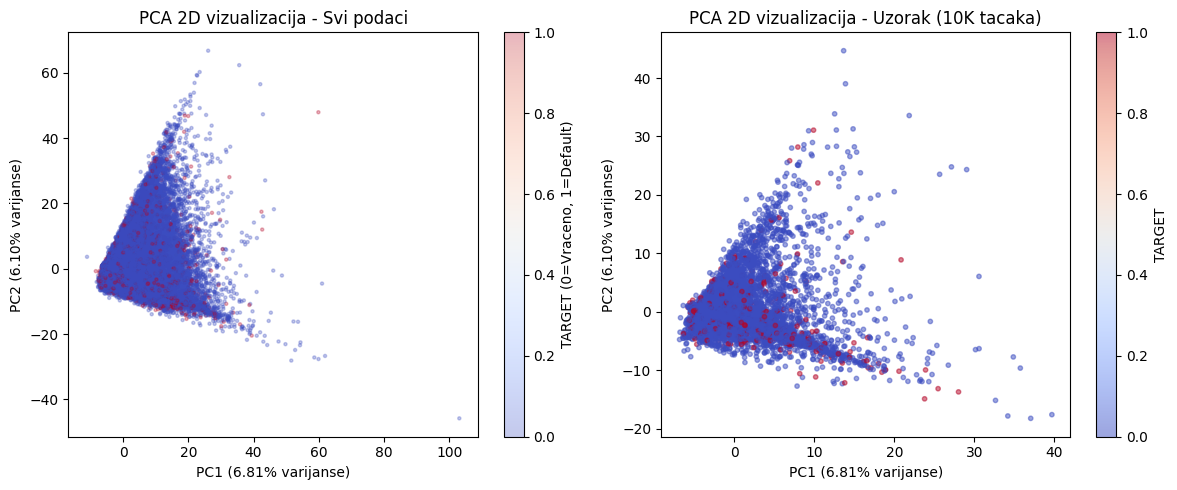

Sacuvano: models/pca_2d_visualization.png


In [44]:
# Vizuelizacija 2D PCA sa TARGET obojenjem
plt.figure(figsize=(12, 5))

# Svi podaci
plt.subplot(1, 2, 1)
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['TARGET'], 
                      cmap='coolwarm', alpha=0.3, s=5)
plt.colorbar(scatter, label='TARGET (0=Vraceno, 1=Default)')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} varijanse)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} varijanse)')
plt.title('PCA 2D vizualizacija - Svi podaci')

# Uzorak za bolju preglednost
plt.subplot(1, 2, 2)
sample_idx = np.random.choice(len(pca_df), size=min(10000, len(pca_df)), replace=False)
sample_df = pca_df.iloc[sample_idx]
scatter = plt.scatter(sample_df['PC1'], sample_df['PC2'], c=sample_df['TARGET'], 
                      cmap='coolwarm', alpha=0.5, s=10)
plt.colorbar(scatter, label='TARGET')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} varijanse)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} varijanse)')
plt.title('PCA 2D vizualizacija - Uzorak (10K tacaka)')

plt.tight_layout()
plt.savefig('models/pca_2d_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sacuvano: models/pca_2d_visualization.png")

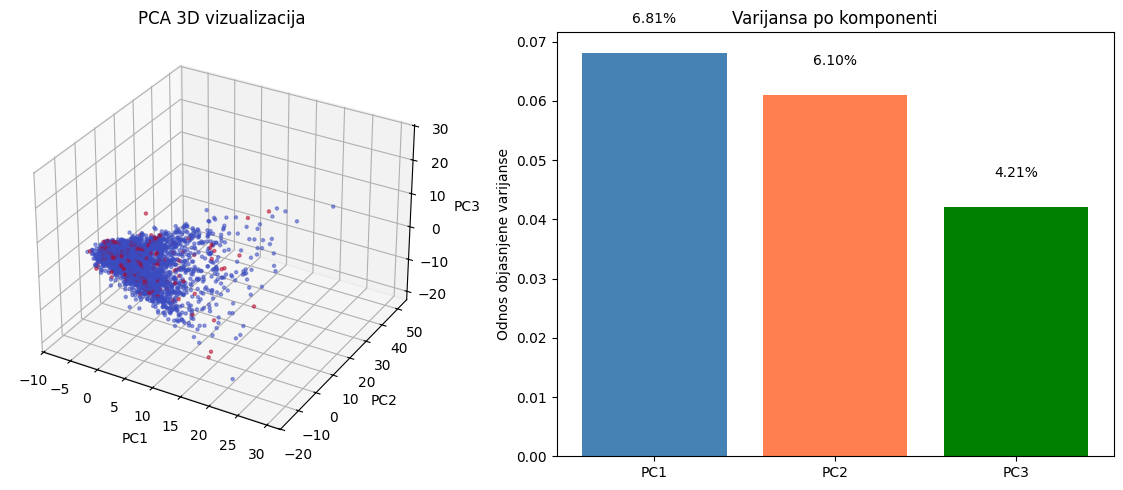

Sacuvano: models/pca_3d_visualization.png


In [45]:
# 3D vizualizacija
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 5))

# Uzorak za 3D grafik (performanse)
sample_idx = np.random.choice(len(X_pca_3d), size=min(5000, len(X_pca_3d)), replace=False)
X_3d_sample = X_pca_3d[sample_idx]
y_sample = y.values[sample_idx]

# 3D scatter
ax = fig.add_subplot(121, projection='3d')
scatter = ax.scatter(X_3d_sample[:, 0], X_3d_sample[:, 1], X_3d_sample[:, 2],
                     c=y_sample, cmap='coolwarm', alpha=0.5, s=5)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA 3D vizualizacija')

# Varijansa po komponenti
ax2 = fig.add_subplot(122)
components = ['PC1', 'PC2', 'PC3']
variances = pca_3d.explained_variance_ratio_
ax2.bar(components, variances, color=['steelblue', 'coral', 'green'])
ax2.set_ylabel('Odnos objasnjene varijanse')
ax2.set_title('Varijansa po komponenti')
for i, v in enumerate(variances):
    ax2.text(i, v + 0.005, f'{v:.2%}', ha='center')

plt.tight_layout()
plt.savefig('models/pca_3d_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sacuvano: models/pca_3d_visualization.png")

## 1.2 K-Means klasterovanje

In [46]:
print("Trazenje optimalnog broja klastera...")

# Koriscenje PCA redukovanih podataka za klasterovanje
# Koristimo vise komponenti za klasterovanje nego za vizuelizaciju
pca_clustering = PCA(n_components=50, random_state=42)
X_pca_cluster = pca_clustering.fit_transform(X_scaled)
print(f"Koristimo {pca_clustering.n_components_} PCA komponenti ({pca_clustering.explained_variance_ratio_.sum():.2%} varijanse)")

# Sample (brzina)
sample_size = min(50000, len(X_pca_cluster))
sample_idx = np.random.choice(len(X_pca_cluster), size=sample_size, replace=False)
X_sample = X_pca_cluster[sample_idx]
y_sample = y.values[sample_idx]

# Testiranje razlicitog broja klastera
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_sample)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_sample, labels))
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouettes[-1]:.4f}")

Trazenje optimalnog broja klastera...
Koristimo 50 PCA komponenti (66.84% varijanse)
K=2: Inertia=8642506.17, Silhouette=0.2275
K=3: Inertia=8091246.92, Silhouette=0.2035
K=4: Inertia=7681603.12, Silhouette=0.1524
K=5: Inertia=7389715.05, Silhouette=0.0678
K=6: Inertia=7185885.68, Silhouette=0.0681
K=7: Inertia=6985446.29, Silhouette=0.0692
K=8: Inertia=6830702.73, Silhouette=0.0692
K=9: Inertia=6699923.39, Silhouette=0.0627
K=10: Inertia=6604340.97, Silhouette=0.0702


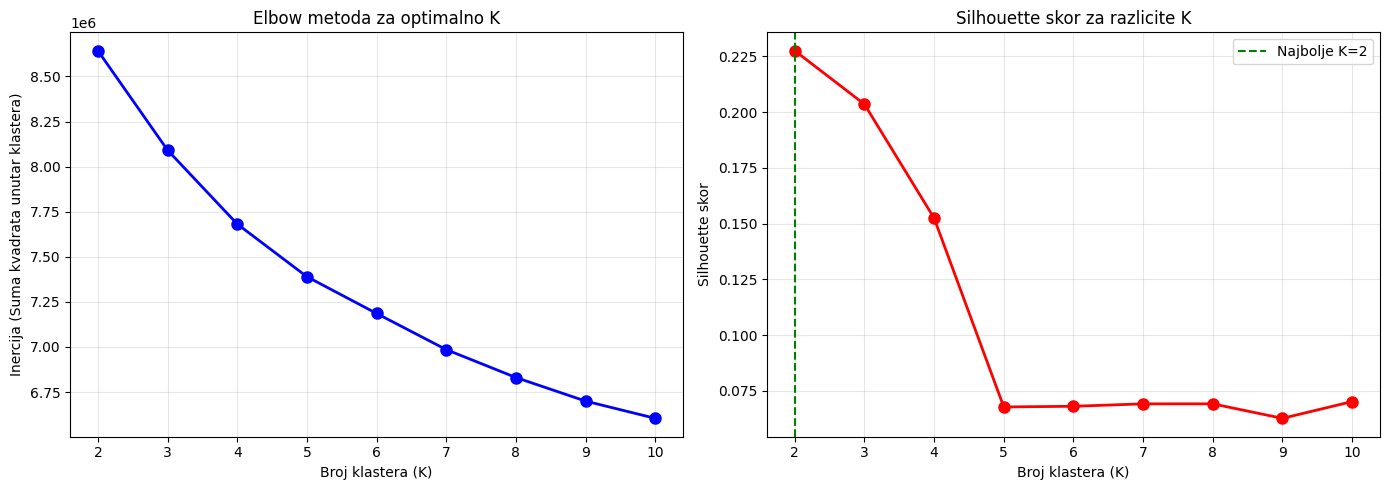


Optimalno K na osnovu Silhouette skora: 2


In [47]:
# Elbow metoda i Silhouette skorovi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow grafik
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Broj klastera (K)')
axes[0].set_ylabel('Inercija (Suma kvadrata unutar klastera)')
axes[0].set_title('Elbow metoda za optimalno K')
axes[0].grid(True, alpha=0.3)

# Silhouette grafik
axes[1].plot(k_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Broj klastera (K)')
axes[1].set_ylabel('Silhouette skor')
axes[1].set_title('Silhouette skor za razlicite K')
axes[1].grid(True, alpha=0.3)

# Markiranje najboljeg silhouette-a
best_k = list(k_range)[np.argmax(silhouettes)]
axes[1].axvline(x=best_k, color='green', linestyle='--', label=f'Najbolje K={best_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig('models/clustering_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nOptimalno K na osnovu Silhouette skora: {best_k}")

In [48]:
# K-Means sa optimalnim K
optimal_k = best_k 
print(f"K-Means sa K={optimal_k}...")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
cluster_labels_sample = kmeans_final.fit_predict(X_sample)

# Evaluacija klasterovanja
print("\nMetrike evaluacije klasterovanja:")
print(f"Silhouette skor: {silhouette_score(X_sample, cluster_labels_sample):.4f}")
print(f"Calinski-Harabasz indeks: {calinski_harabasz_score(X_sample, cluster_labels_sample):.2f}")
print(f"Davies-Bouldin indeks: {davies_bouldin_score(X_sample, cluster_labels_sample):.4f}")

# Distribucija klastera
print(f"\nDistribucija klastera:")
unique, counts = np.unique(cluster_labels_sample, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Klaster {cluster}: {count} uzoraka ({count/len(cluster_labels_sample)*100:.1f}%)")

K-Means sa K=2...

Metrike evaluacije klasterovanja:
Silhouette skor: 0.2275
Calinski-Harabasz indeks: 3856.77
Davies-Bouldin indeks: 3.0351

Distribucija klastera:
  Klaster 0: 38350 uzoraka (76.7%)
  Klaster 1: 11650 uzoraka (23.3%)


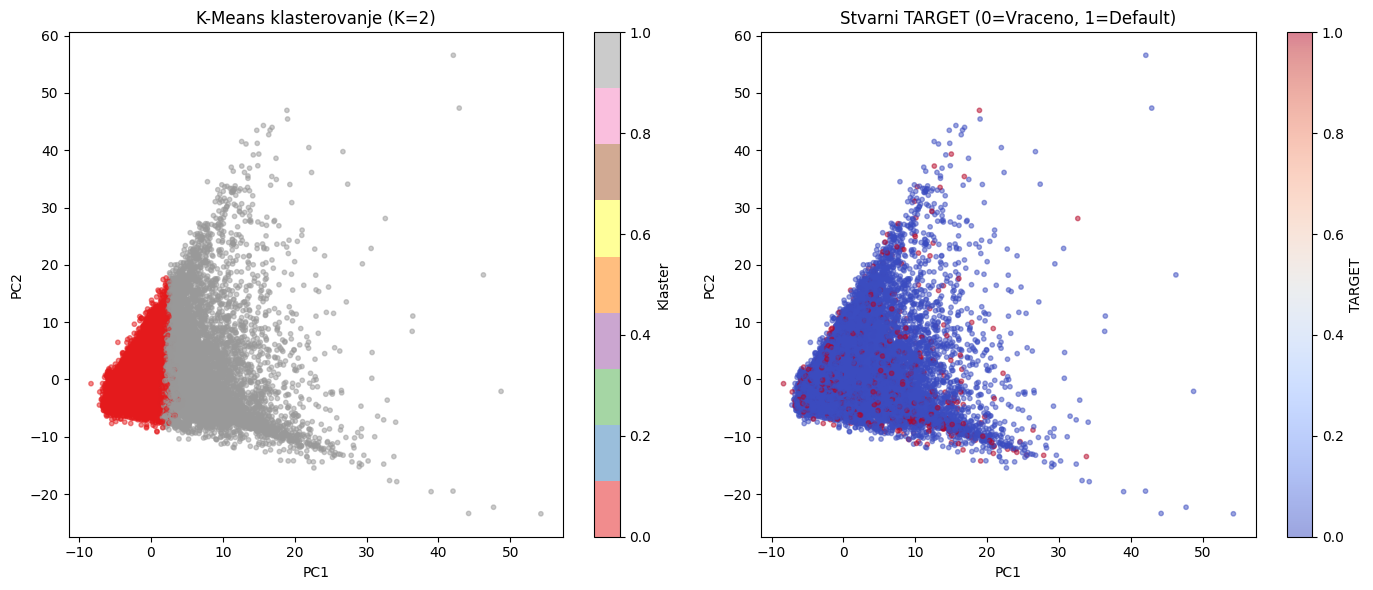

Sacuvano: models/kmeans_vs_target.png


In [49]:
# Vizualizacija klastera u 2D PCA prostoru
X_pca_2d_sample = pca_2d.transform(scaler.transform(X.iloc[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafik 1: K-Means klasteri
scatter1 = axes[0].scatter(X_pca_2d_sample[:, 0], X_pca_2d_sample[:, 1], 
                           c=cluster_labels_sample, cmap='Set1', alpha=0.5, s=10)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title(f'K-Means klasterovanje (K={optimal_k})')
plt.colorbar(scatter1, ax=axes[0], label='Klaster')

# Grafik 2: Stvarni TARGET
scatter2 = axes[1].scatter(X_pca_2d_sample[:, 0], X_pca_2d_sample[:, 1], 
                           c=y_sample, cmap='coolwarm', alpha=0.5, s=10)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Stvarni TARGET (0=Vraceno, 1=Default)')
plt.colorbar(scatter2, ax=axes[1], label='TARGET')

plt.tight_layout()
plt.savefig('models/kmeans_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sacuvano: models/kmeans_vs_target.png")

In [50]:
# Analiza veze izmedju klastera i TARGET-a
print("Analiza klastera i TARGET-a:")
print("="*50)

cluster_target_df = pd.DataFrame({
    'Cluster': cluster_labels_sample,
    'TARGET': y_sample
})

# Racunanje stope defaulta po klasteru
for cluster in sorted(cluster_target_df['Cluster'].unique()):
    cluster_data = cluster_target_df[cluster_target_df['Cluster'] == cluster]
    default_rate = cluster_data['TARGET'].mean()
    size = len(cluster_data)
    print(f"\nKlaster {cluster}:")
    print(f"  Velicina: {size} ({size/len(cluster_target_df)*100:.1f}%)")
    print(f"  Stopa defaulta: {default_rate:.2%}")
    print(f"  Bez defaulta: {(1-default_rate)*100:.1f}%")

# Unakrsna tabelacija
print("\n" + "="*50)
print("Unakrsna tabelacija (Klaster x TARGET):")
crosstab = pd.crosstab(cluster_target_df['Cluster'], cluster_target_df['TARGET'], 
                       margins=True, normalize='index')
print(crosstab.round(3))

Analiza klastera i TARGET-a:

Klaster 0:
  Velicina: 38350 (76.7%)
  Stopa defaulta: 8.18%
  Bez defaulta: 91.8%

Klaster 1:
  Velicina: 11650 (23.3%)
  Stopa defaulta: 7.57%
  Bez defaulta: 92.4%

Unakrsna tabelacija (Klaster x TARGET):
TARGET       0      1
Cluster              
0        0.918  0.082
1        0.924  0.076
All      0.920  0.080


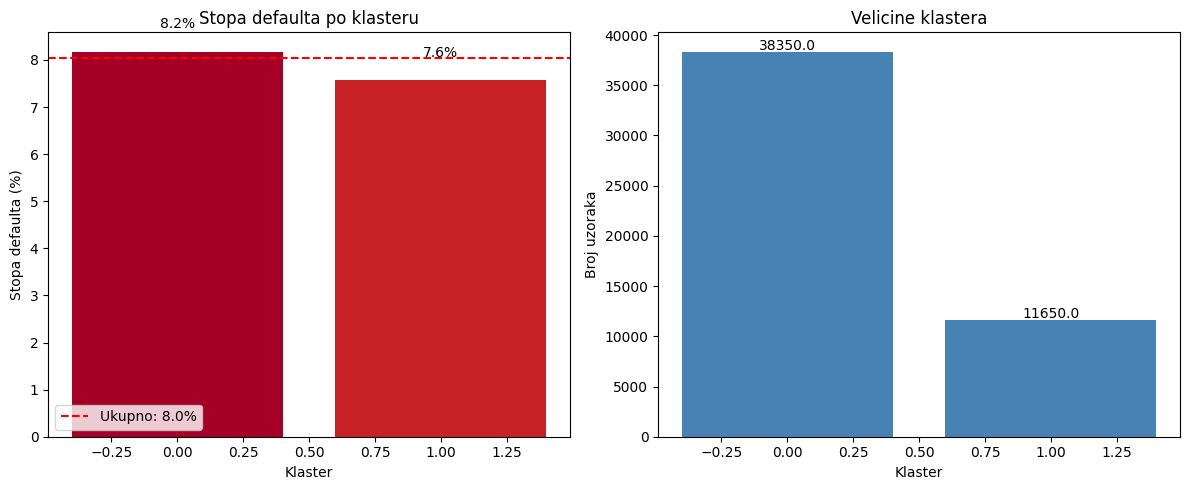

In [51]:
# Vizualizacija stope defaulta po klasteru
cluster_stats = cluster_target_df.groupby('Cluster')['TARGET'].agg(['mean', 'count'])
cluster_stats.columns = ['Default_Rate', 'Count']
cluster_stats = cluster_stats.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Stopa defaulta po klasteru
colors = plt.cm.RdYlGn_r(cluster_stats['Default_Rate'] / cluster_stats['Default_Rate'].max())
axes[0].bar(cluster_stats['Cluster'], cluster_stats['Default_Rate'] * 100, color=colors)
axes[0].set_xlabel('Klaster')
axes[0].set_ylabel('Stopa defaulta (%)')
axes[0].set_title('Stopa defaulta po klasteru')
axes[0].axhline(y=y_sample.mean()*100, color='red', linestyle='--', label=f'Ukupno: {y_sample.mean()*100:.1f}%')
axes[0].legend()
for i, row in cluster_stats.iterrows():
    axes[0].text(row['Cluster'], row['Default_Rate']*100 + 0.5, f"{row['Default_Rate']*100:.1f}%", ha='center')

# Velicine klastera
axes[1].bar(cluster_stats['Cluster'], cluster_stats['Count'], color='steelblue')
axes[1].set_xlabel('Klaster')
axes[1].set_ylabel('Broj uzoraka')
axes[1].set_title('Velicine klastera')
for i, row in cluster_stats.iterrows():
    axes[1].text(row['Cluster'], row['Count'] + 200, f"{row['Count']}", ha='center')

plt.tight_layout()
plt.savefig('models/cluster_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.3 t-SNE vizualizacija

In [52]:
# t-SNE na manjem uzorku (racunski zahtevno)
print("t-SNE (moze potrajati par minuta)...")

tsne_sample_size = min(10000, len(X_sample))
tsne_idx = np.random.choice(len(X_sample), size=tsne_sample_size, replace=False)
X_tsne_input = X_sample[tsne_idx]
y_tsne = y_sample[tsne_idx]
cluster_tsne = cluster_labels_sample[tsne_idx]

# Primena t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, verbose=1)
X_tsne = tsne.fit_transform(X_tsne_input)

print("t-SNE zavrseno!")

t-SNE (moze potrajati par minuta)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.002s...
[t-SNE] Computed neighbors for 10000 samples in 0.362s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 2.715124
[t-SNE] KL divergence after 250 iterations with early exaggeration: 91.605759
[t-SNE] KL divergence after 1000 iteration

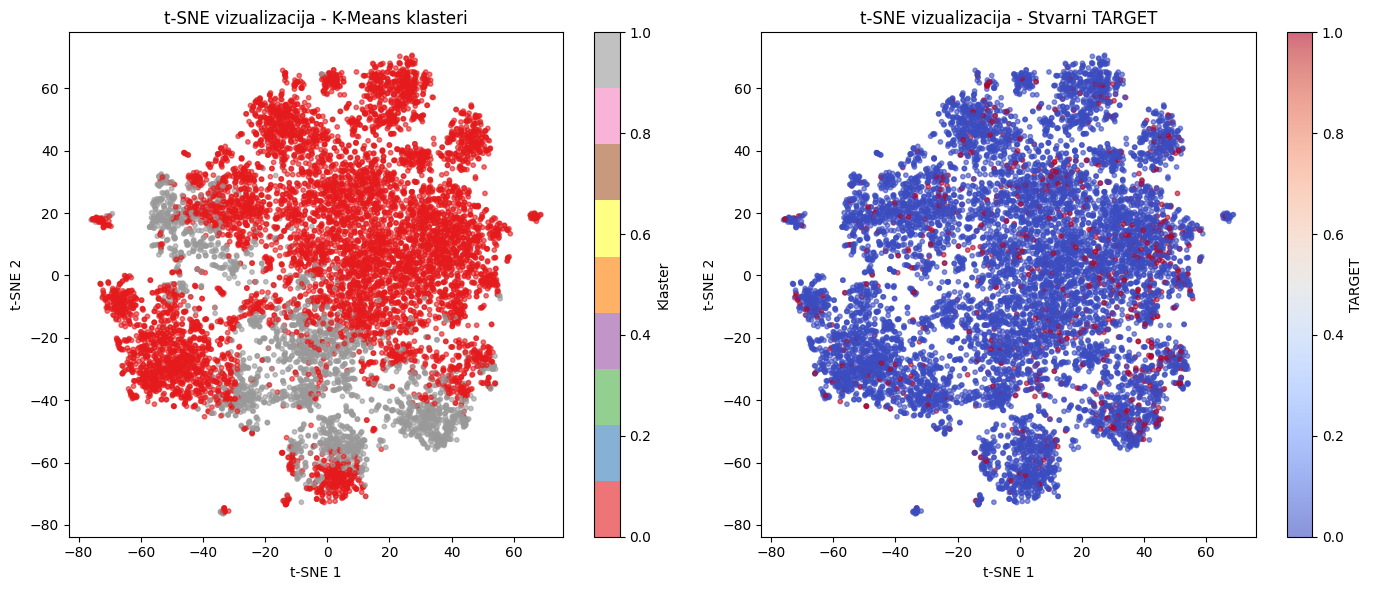

Sacuvano: models/tsne_visualization.png


In [53]:
# Vizualizacija t-SNE rezultata
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# t-SNE sa klasterima
scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_tsne, 
                           cmap='Set1', alpha=0.6, s=10)
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].set_title('t-SNE vizualizacija - K-Means klasteri')
plt.colorbar(scatter1, ax=axes[0], label='Klaster')

# t-SNE sa TARGET-om
scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_tsne, 
                           cmap='coolwarm', alpha=0.6, s=10)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE vizualizacija - Stvarni TARGET')
plt.colorbar(scatter2, ax=axes[1], label='TARGET')

plt.tight_layout()
plt.savefig('models/tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sacuvano: models/tsne_visualization.png")

## 1.4 Cuvanje modela klasterovanja

In [54]:
# Primena K-Means na ceo skup podataka i cuvanje
print("Treniranje finalnog K-Means modela na celom PCA-transformisanom skupu...")

# Transformacija celog skupa pomocu PCA
X_full_pca = pca_clustering.transform(X_scaled)

# K-Means na celom skupu
kmeans_full = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
full_cluster_labels = kmeans_full.fit_predict(X_full_pca)

# Cuvanje modela
joblib.dump(kmeans_full, 'models/kmeans_clustering.joblib')
joblib.dump(pca_clustering, 'models/pca_clustering.joblib')
joblib.dump(scaler, 'models/scaler_clustering.joblib')

print(f"\nModeli sacuvani:")
print("  - models/kmeans_clustering.joblib")
print("  - models/pca_clustering.joblib")
print("  - models/scaler_clustering.joblib")

# Finalna distribucija klastera
print(f"\nFinalna distribucija klastera (ceo skup):")
unique, counts = np.unique(full_cluster_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    default_rate = y[full_cluster_labels == cluster].mean()
    print(f"  Klaster {cluster}: {count:,} uzoraka ({count/len(full_cluster_labels)*100:.1f}%) - Stopa defaulta: {default_rate:.2%}")

Treniranje finalnog K-Means modela na celom PCA-transformisanom skupu...

Modeli sacuvani:
  - models/kmeans_clustering.joblib
  - models/pca_clustering.joblib
  - models/scaler_clustering.joblib

Finalna distribucija klastera (ceo skup):
  Klaster 0: 241,857 uzoraka (78.6%) - Stopa defaulta: 8.04%
  Klaster 1: 65,654 uzoraka (21.4%) - Stopa defaulta: 8.19%


---
# Deo 2: XGBoost i LightGBM

XGBoost i LightGBM su napredne implementacije gradient boosting-a koje cesto postizu bolje performanse od sklearn GradientBoosting klasifikatora. Koriste optimizovane algoritme za treniranje i imaju ugradjenu podrsku za balansiranje klasa.

## 2.1 Priprema podataka za treniranje

In [55]:
# Podela podataka
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Trening skup: {X_train.shape}")
print(f"Test skup: {X_test.shape}")
print(f"\nDistribucija klasa u trening skupu:")
print(y_train.value_counts(normalize=True))

# Skaliranje atributa
scaler_boost = StandardScaler()
X_train_scaled = scaler_boost.fit_transform(X_train)
X_test_scaled = scaler_boost.transform(X_test)

Trening skup: (246008, 301)
Test skup: (61503, 301)

Distribucija klasa u trening skupu:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


## 2.2 XGBoost klasifikator

In [56]:
import xgboost as xgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    use_label_encoder=False
)

xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=50
)

scale_pos_weight: 11.39
[0]	validation_0-auc:0.72364
[50]	validation_0-auc:0.77526
[100]	validation_0-auc:0.78127
[150]	validation_0-auc:0.78195
[199]	validation_0-auc:0.78157


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [57]:
# Evaluacija XGBoost
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Unakrsna validacija za XGBoost
cv_scores_xgb = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5, scoring='roc_auc')

print(f"Tacnost:    {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Preciznost: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Odziv:      {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-skor:    {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:    {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"CV ROC-AUC: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std():.4f})")

print(classification_report(y_test, y_pred_xgb))

Tacnost:    0.7621
Preciznost: 0.1994
Odziv:      0.6457
F1-skor:    0.3047
ROC-AUC:    0.7816
CV ROC-AUC: 0.7767 (+/- 0.0046)
              precision    recall  f1-score   support

           0       0.96      0.77      0.86     56538
           1       0.20      0.65      0.30      4965

    accuracy                           0.76     61503
   macro avg       0.58      0.71      0.58     61503
weighted avg       0.90      0.76      0.81     61503



## 2.3 LightGBM klasifikator

In [58]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    eval_metric='auc'
)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [59]:
y_pred_lgb = lgb_model.predict(X_test_scaled)
y_proba_lgb = lgb_model.predict_proba(X_test_scaled)[:, 1]

cv_scores_lgb = cross_val_score(lgb_model, X_train_scaled, y_train, cv=5, scoring='roc_auc')

print(f"Tacnost:    {accuracy_score(y_test, y_pred_lgb):.4f}")
print(f"Preciznost: {precision_score(y_test, y_pred_lgb):.4f}")
print(f"Odziv:      {recall_score(y_test, y_pred_lgb):.4f}")
print(f"F1-skor:    {f1_score(y_test, y_pred_lgb):.4f}")
print(f"ROC-AUC:    {roc_auc_score(y_test, y_proba_lgb):.4f}")
print(f"CV ROC-AUC: {cv_scores_lgb.mean():.4f} (+/- {cv_scores_lgb.std():.4f})")

print(classification_report(y_test, y_pred_lgb))

Tacnost:    0.7452
Preciznost: 0.1930
Odziv:      0.6779
F1-skor:    0.3005
ROC-AUC:    0.7837
CV ROC-AUC: 0.7802 (+/- 0.0050)
              precision    recall  f1-score   support

           0       0.96      0.75      0.84     56538
           1       0.19      0.68      0.30      4965

    accuracy                           0.75     61503
   macro avg       0.58      0.71      0.57     61503
weighted avg       0.90      0.75      0.80     61503



## 2.4 Poredjenje svih modela

In [60]:
# Ucitavanje prethodnih rezultata za poredjenje
print("Ucitavanje prethodnih rezultata modela...")

try:
    previous_results = pd.read_csv('model_comparison_advanced.csv')
    print("Prethodni rezultati ucitani!")
except:
    previous_results = pd.DataFrame()
    print("Prethodni rezultati nisu pronadjeni, kreiranje novog poredjenja.")

# Kreiranje DataFrame-a sa CV skorovima
new_results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_lgb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_lgb)
    ],
    'CV_Mean': [
        cv_scores_xgb.mean(),
        cv_scores_lgb.mean()
    ],
    'CV_Std': [
        cv_scores_xgb.std(),
        cv_scores_lgb.std()
    ]
})

print("\nRezultati novih modela:")
print(new_results.to_string(index=False))

Ucitavanje prethodnih rezultata modela...
Prethodni rezultati ucitani!

Rezultati novih modela:
   Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  CV_Mean   CV_Std
 XGBoost  0.762093   0.199391 0.645720  0.304695 0.781565 0.776685 0.004630
LightGBM  0.745183   0.193016 0.677946  0.300482 0.783672 0.780205 0.004966


In [61]:
if not previous_results.empty:
    all_results = pd.concat([previous_results, new_results], ignore_index=True)
else:
    all_results = new_results

# Sortiranje po ROC-AUC
all_results_sorted = all_results.sort_values('ROC-AUC', ascending=False)

print("\nPoredjenje svih modela (sortirano po ROC-AUC):")
print("="*80)
print(all_results_sorted.to_string(index=False))

# Cuvanje rezultata
all_results_sorted.to_csv('model_comparison_with_boosting.csv', index=False)
print("\nRezultati sacuvani: model_comparison_with_boosting.csv")


Poredjenje svih modela (sortirano po ROC-AUC):
                 Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  CV_Mean   CV_Std
              LightGBM  0.745183   0.193016 0.677946  0.300482 0.783672 0.780205 0.004966
               XGBoost  0.762093   0.199391 0.645720  0.304695 0.781565 0.776685 0.004630
  4. Gradient Boosting  0.919695   0.532020 0.043505  0.080432 0.779842      NaN      NaN
1. Logistic Regression  0.705917   0.172441 0.695670  0.276375 0.770438      NaN      NaN
           7. AdaBoost  0.919760   0.615385 0.016113  0.031403 0.766374      NaN      NaN
      3. Random Forest  0.757280   0.188325 0.606244  0.287378 0.759627      NaN      NaN
      2. Decision Tree  0.672439   0.147887 0.642095  0.240404 0.694076      NaN      NaN
        6. Naive Bayes  0.185324   0.084147 0.919839  0.154189 0.611031      NaN      NaN
5. K-Nearest Neighbors  0.913809   0.158537 0.015710  0.028587 0.549233      NaN      NaN

Rezultati sacuvani: model_comparison_with_boosting.

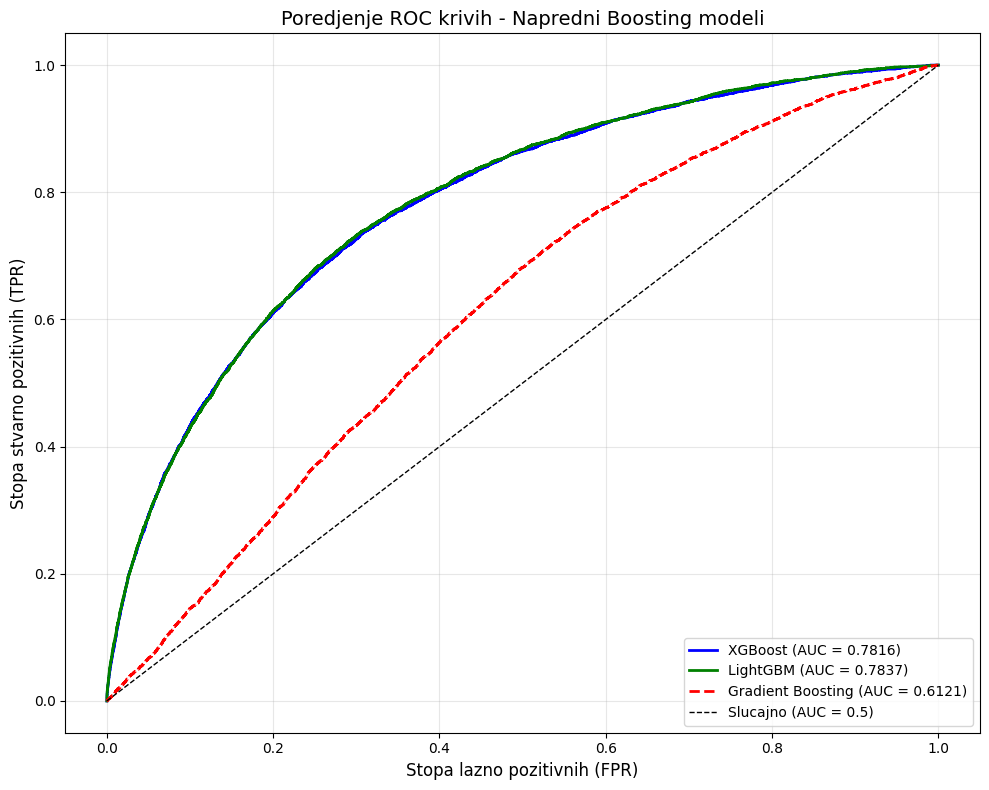

Sacuvano: models/roc_comparison_boosting.png


In [62]:
# Vizualizacija ROC krivih za XGBoost i LightGBM
plt.figure(figsize=(10, 8))

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, 'b-', linewidth=2, 
         label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb):.4f})')

# LightGBM ROC
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_proba_lgb)
plt.plot(fpr_lgb, tpr_lgb, 'g-', linewidth=2, 
         label=f'LightGBM (AUC = {roc_auc_score(y_test, y_proba_lgb):.4f})')

# Ucitavanje Gradient Boosting modela za poredjenje
try:
    gb_model = joblib.load('models/advanced_4_Gradient_Boosting.joblib')
    gb_scaler = joblib.load('models/scaler_advanced.joblib')
    # Uklanjamo SK_ID_CURR jer GB model iz NB02 nije treniran sa tom kolonom
    X_test_gb = X_test.drop(columns=['SK_ID_CURR'], errors='ignore')
    X_test_gb = gb_scaler.transform(X_test_gb)
    y_proba_gb = gb_model.predict_proba(X_test_gb)[:, 1]
    fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)
    plt.plot(fpr_gb, tpr_gb, 'r--', linewidth=2, 
             label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, y_proba_gb):.4f})')
except Exception as e:
    print(f"Neuspelo ucitavanje Gradient Boosting modela: {e}")

# Slucajna bazna linija
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Slucajno (AUC = 0.5)')

plt.xlabel('Stopa lazno pozitivnih (FPR)', fontsize=12)
plt.ylabel('Stopa stvarno pozitivnih (TPR)', fontsize=12)
plt.title('Poredjenje ROC krivih - Napredni Boosting modeli', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models/roc_comparison_boosting.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sacuvano: models/roc_comparison_boosting.png")

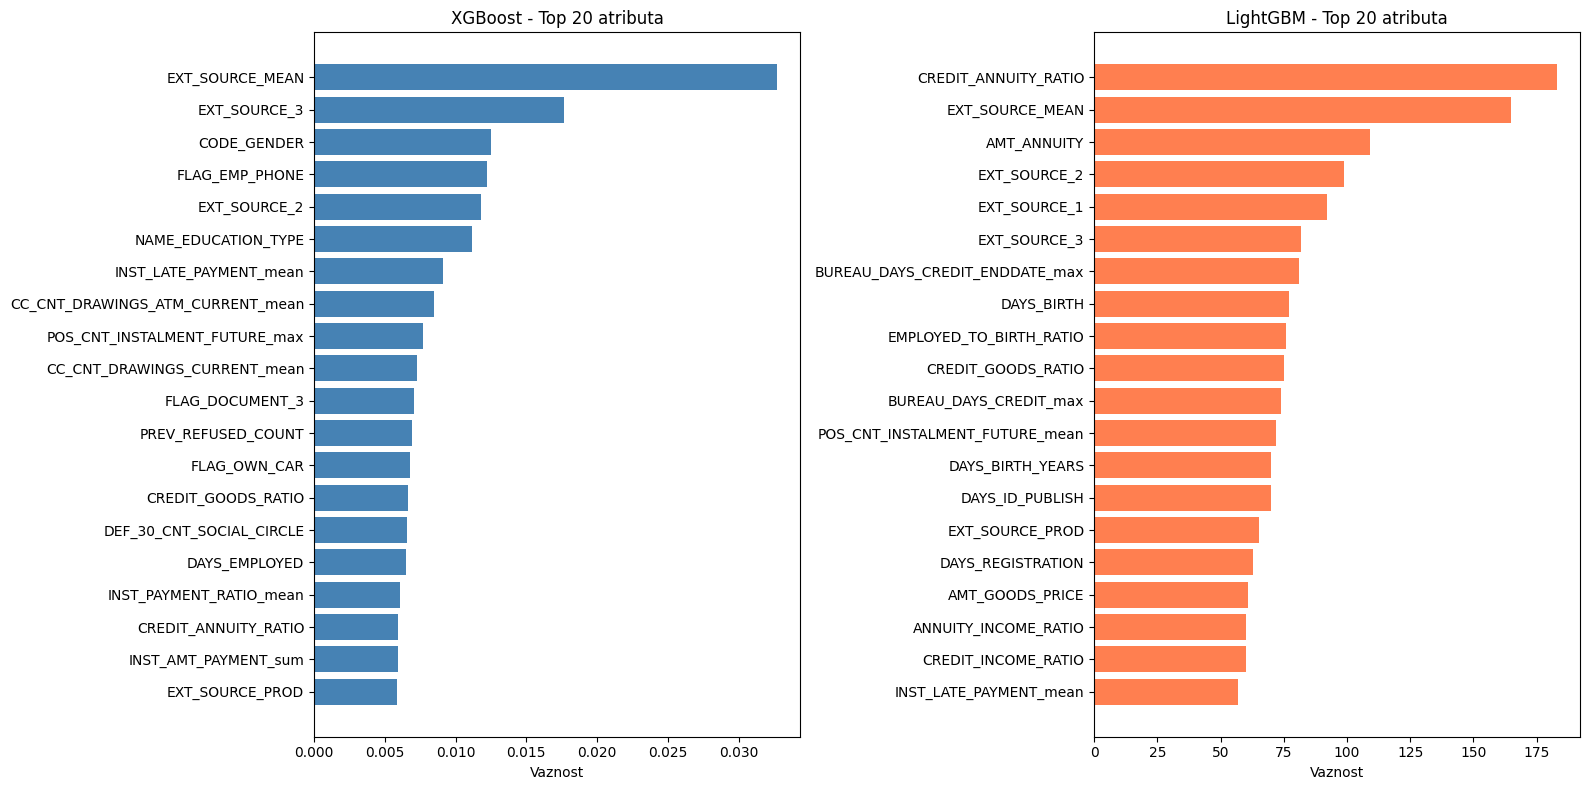

Sacuvano: models/feature_importance_boosting.png


In [63]:
# Poredjenje vaznosti atributa
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# XGBoost vaznost atributa
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

axes[0].barh(range(len(xgb_importance)), xgb_importance['Importance'], color='steelblue')
axes[0].set_yticks(range(len(xgb_importance)))
axes[0].set_yticklabels(xgb_importance['Feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Vaznost')
axes[0].set_title('XGBoost - Top 20 atributa')

# LightGBM vaznost atributa
lgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

axes[1].barh(range(len(lgb_importance)), lgb_importance['Importance'], color='coral')
axes[1].set_yticks(range(len(lgb_importance)))
axes[1].set_yticklabels(lgb_importance['Feature'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Vaznost')
axes[1].set_title('LightGBM - Top 20 atributa')

plt.tight_layout()
plt.savefig('models/feature_importance_boosting.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sacuvano: models/feature_importance_boosting.png")

## 2.5 Cuvanje modela

In [64]:
# Cuvanje XGBoost i LightGBM modela
print("Cuvanje modela...")

joblib.dump(xgb_model, 'models/8_XGBoost.joblib')
joblib.dump(lgb_model, 'models/9_LightGBM.joblib')
joblib.dump(scaler_boost, 'models/scaler_boosting.joblib')

print("Modeli sacuvani:")
print("  - models/8_XGBoost.joblib")
print("  - models/9_LightGBM.joblib")
print("  - models/scaler_boosting.joblib")

Cuvanje modela...
Modeli sacuvani:
  - models/8_XGBoost.joblib
  - models/9_LightGBM.joblib
  - models/scaler_boosting.joblib


## 2.6 Analiza krive ucenja

Kriva ucenja pokazuje kako se performanse modela menjaju sa povecanjem velicine trening skupa. Ako je razlika izmedju trening i validacionog skora mala, model nije prefit-ovan.

Generisanje krive ucenja za LightGBM...


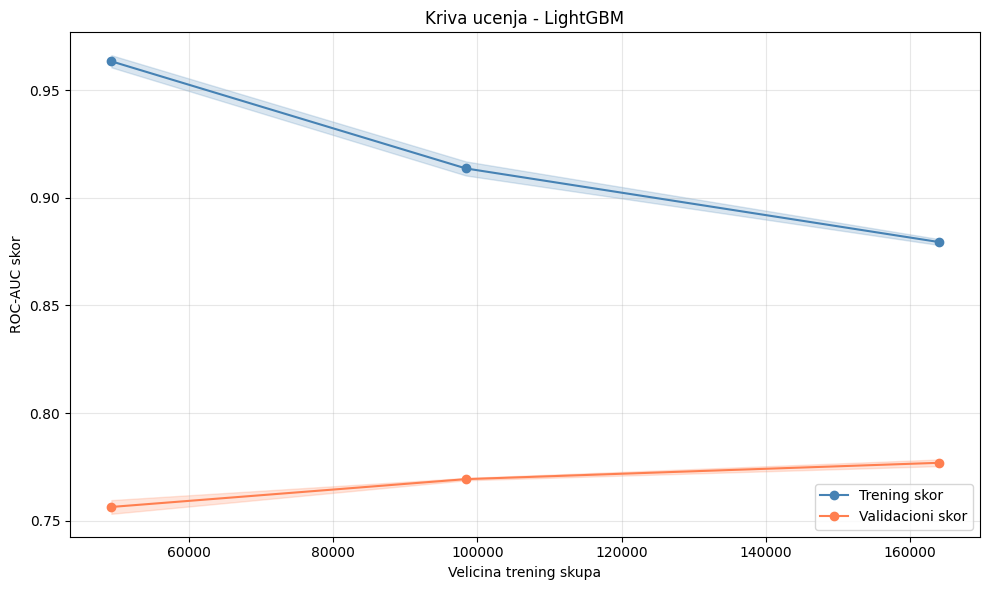


Trening skorovi: [0.96345386 0.9136724  0.8795022 ]
Validacioni skorovi: [0.7563812 0.7693105 0.7768926]

Razlika (trening - validacija): [0.20707266 0.1443619  0.10260961]

Ako je razlika mala, model nije prefit-ovan.
Sacuvano: models/learning_curve_lightgbm.png


In [39]:
from sklearn.model_selection import learning_curve

# Kriva ucenja za LightGBM (najbolji model)
print("Generisanje krive ucenja za LightGBM...")

train_sizes = [0.3, 0.6, 1.0]
train_sizes_abs, train_scores, val_scores = learning_curve(
    lgb_model, 
    X_train_scaled, 
    y_train,
    train_sizes=train_sizes,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

# Racunanje srednje vrednosti i standardne devijacije
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Crtanje krive ucenja
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, train_mean, 'o-', color='steelblue', label='Trening skor')
plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, 
                 alpha=0.2, color='steelblue')
plt.plot(train_sizes_abs, val_mean, 'o-', color='coral', label='Validacioni skor')
plt.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, 
                 alpha=0.2, color='coral')

plt.xlabel('Velicina trening skupa')
plt.ylabel('ROC-AUC skor')
plt.title('Kriva ucenja - LightGBM')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models/learning_curve_lightgbm.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTrening skorovi: {train_mean}")
print(f"Validacioni skorovi: {val_mean}")
print(f"\nRazlika (trening - validacija): {train_mean - val_mean}")
print("\nAko je razlika mala, model nije prefit-ovan.")
print("Sacuvano: models/learning_curve_lightgbm.png")

## Rezime

### Analiza klasterovanja
- Primenjen K-Means algoritam za otkrivanje prirodnih grupa u podacima
- Vizualizacija podataka u 2D (PCA) i t-SNE prostoru
- Analizirana veza izmedju klastera i stope defaulta
- Pronadjeni klasteri sa razlicitim profilima rizika

### Rezultati XGBoost i LightGBM
Oba modela su trenirana sa balansiranjem klasa (`scale_pos_weight = 11.39`).

Poredjenje sa prethodnim najboljim modelom (Gradient Boosting ROC-AUC: 0.7798):
- **XGBoost**: ROC-AUC = 0.782
- **LightGBM**: ROC-AUC = 0.784

### Kljucni nalazi
1. Klasterovanje otkriva prirodne segmente klijenata sa razlicitim nivoima rizika
2. XGBoost i LightGBM postizu bolje performanse od prethodnih modela
3. Obrasci vaznosti atributa su konzistentni izmedju modela

In [ ]:
print("="*60)
print("FINALNI ZAKLJUCAK")
print("="*60)

print("\n1. KLASTEROVANJE:")
print(f"   - Optimalno K: {optimal_k} klastera")
print(f"   - Silhouette skor: {silhouette_score(X_sample, cluster_labels_sample):.4f}")

print("\n2. KLASIFIKACIJA (Novi modeli):")
print(f"   XGBoost:")
print(f"     ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"     CV ROC-AUC: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std():.4f})")
print(f"   LightGBM:")
print(f"     ROC-AUC: {roc_auc_score(y_test, y_proba_lgb):.4f}")
print(f"     CV ROC-AUC: {cv_scores_lgb.mean():.4f} (+/- {cv_scores_lgb.std():.4f})")

print("\n3. VALIDACIJA MODELA:")
print("   - Unakrsna validacija pokazuje konzistentne performanse")
print("   - Niska standardna devijacija CV ukazuje na stabilne modele")

print("\n4. KREIRANI FAJLOVI:")
print("   - models/kmeans_clustering.joblib")
print("   - models/pca_clustering.joblib")
print("   - models/8_XGBoost.joblib")
print("   - models/9_LightGBM.joblib")
print("   - models/learning_curve_lightgbm.png")
print("   - model_comparison_with_boosting.csv")

Finalni zaključak

1. Klasterovanje:
   - Optimal K: 2 clusters
   - Silhouette Score: 0.2058

2. Klasifikacija:
   XGBoost:
     ROC-AUC: 0.7816
     CV ROC-AUC: 0.7767 (+/- 0.0046)
   LightGBM:
     ROC-AUC: 0.7837
     CV ROC-AUC: 0.7802 (+/- 0.0050)

3. MODEL VALIDATION:
   - Cross-validation shows consistent performance across folds
   - Low CV standard deviation indicates stable models

4. FILES CREATED:
   - models/kmeans_clustering.joblib
   - models/pca_clustering.joblib
   - models/8_XGBoost.joblib
   - models/9_LightGBM.joblib
   - models/learning_curve_lightgbm.png
   - model_comparison_with_boosting.csv
